# Standalone Algorithm Legend

Generate a standalone PDF legend for any algorithm combination used by the HomOPT convergence plots. Edit `ALGORITHMS`, label overrides, and legend layout settings, then run the save cell.

In [11]:
from __future__ import annotations

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "homopt").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

MPLCONFIGDIR = REPO_ROOT / "tmp" / "matplotlib"
XDG_CACHE_HOME = REPO_ROOT / "tmp" / "fontconfig"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_HOME.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_HOME))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from homopt.experiments._labels import CONVEX_METHOD_LABELS, STIEFEL_METHOD_LABELS
from homopt.viz.style import ALGORITHM_COLORS, ALGORITHM_LINE_STYLES, PAPER_STYLE, style_legend

OUTPUT_DIR = REPO_ROOT / "results" / "paper_figures" / "legends"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/Users/lem/Projects/HomOPT/results/paper_figures/legends')

## Choose The Algorithm Set

Use `STIEFEL_METHOD_LABELS` for Stiefel plots and `CONVEX_METHOD_LABELS` for SOCP/SOCP-EQ plots. The algorithm keys must match the keys used in experiment records.

In [12]:
PRESETS = {
    "socp_eq_main": ["PGD", "Prox-Penalty", "Prox-ALM", "Prox-ALM-EQ", "Prox-Hom-ALM"],
    "stiefel_main": [
        "Prox-Penalty",
        "Prox-ALM",
        "StiefelRetractionPenalty",
        "StiefelRetractionALM",
        "Prox-Hom-ALM",
    ],
    "stiefel_retraction_only": ["StiefelRetractionPenalty", "StiefelRetractionALM"],
    "palm_vs_hom_palm": ["Prox-ALM", "Prox-Hom-ALM"],
}

ALGORITHMS = PRESETS["stiefel_main"]
BASE_LABELS = STIEFEL_METHOD_LABELS

# Override displayed names for specific algorithms here.
LABEL_OVERRIDES = {
    "Prox-Penalty": "PPP",
    "Prox-ALM": "ALM",
    "Prox-ALM-EQ": "PALM",
    "Prox-Hom-ALM": "Hom-PALM",
    "StiefelRetractionPenalty": "Retraction-Penalty",
    "StiefelRetractionALM": "Retraction-ALM",
}
LABELS = {**BASE_LABELS, **LABEL_OVERRIDES}

STEM = "stiefel_main"

# Layout controls.
N_COL = 5
FIGSIZE = (7.2, 1.25)
FONT_SIZE = PAPER_STYLE["compact_legend_fontsize"]
HANDLE_LENGTH = 2.6
HANDLE_TEXT_PAD = 0.7
COLUMN_SPACING = 1.4
LABEL_SPACING = 0.5
BORDER_PAD = 0.5
BORDER_AXES_PAD = 0.0
PAD_INCHES = 0.04
FRAME_ON = True
TRANSPARENT = True

[(name, LABELS.get(name, name)) for name in ALGORITHMS]

[('Prox-Penalty', 'PPP'),
 ('Prox-ALM', 'ALM'),
 ('StiefelRetractionPenalty', 'Retraction-Penalty'),
 ('StiefelRetractionALM', 'Retraction-ALM'),
 ('Prox-Hom-ALM', 'Hom-PALM')]

In [13]:
def legend_handles(algorithms, labels):
    handles = []
    for method in algorithms:
        handles.append(
            Line2D(
                [0],
                [0],
                color=ALGORITHM_COLORS.get(method, "#4C78A8"),
                linestyle=ALGORITHM_LINE_STYLES.get(method, "-"),
                linewidth=PAPER_STYLE["curve_linewidth"],
                label=labels.get(method, method),
            )
        )
    return handles


def save_algorithm_legend(
    algorithms,
    *,
    labels,
    stem,
    ncol=3,
    figsize=(7.2, 1.25),
    fontsize=None,
    handlelength=2.6,
    handletextpad=0.7,
    columnspacing=1.4,
    labelspacing=0.5,
    borderpad=0.5,
    borderaxespad=0.0,
    pad_inches=0.04,
    frameon=True,
    transparent=True,
):
    fig = plt.figure(figsize=figsize)
    if fontsize is None:
        fontsize = PAPER_STYLE["compact_legend_fontsize"]
    legend = fig.legend(
        handles=legend_handles(algorithms, labels),
        loc="center",
        ncol=ncol,
        frameon=frameon,
        fontsize=fontsize,
        handlelength=handlelength,
        handletextpad=handletextpad,
        columnspacing=columnspacing,
        labelspacing=labelspacing,
        borderpad=borderpad,
        borderaxespad=borderaxespad,
    )
    style_legend(legend)
    path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(
        path,
        dpi=PAPER_STYLE["dpi"],
        bbox_inches="tight",
        pad_inches=pad_inches,
        transparent=transparent,
    )
    plt.close(fig)
    return path

In [14]:
path = save_algorithm_legend(
    ALGORITHMS,
    labels=LABELS,
    stem=STEM,
    ncol=N_COL,
    figsize=FIGSIZE,
    fontsize=FONT_SIZE,
    handlelength=HANDLE_LENGTH,
    handletextpad=HANDLE_TEXT_PAD,
    columnspacing=COLUMN_SPACING,
    labelspacing=LABEL_SPACING,
    borderpad=BORDER_PAD,
    borderaxespad=BORDER_AXES_PAD,
    pad_inches=PAD_INCHES,
    frameon=FRAME_ON,
    transparent=TRANSPARENT,
)
path

PosixPath('/Users/lem/Projects/HomOPT/results/paper_figures/legends/stiefel_main.pdf')

## Optional: Batch Export Presets

Run this cell if you want one legend file per preset.

In [15]:
# for preset_name, algorithms in PRESETS.items():
#     base_labels = STIEFEL_METHOD_LABELS if preset_name.startswith("stiefel") else CONVEX_METHOD_LABELS
#     labels = {**base_labels, **LABEL_OVERRIDES}
#     save_algorithm_legend(
#         algorithms,
#         labels=labels,
#         stem=f"{preset_name}_legend",
#         ncol=min(3, len(algorithms)),
#         fontsize=FONT_SIZE,
#         columnspacing=COLUMN_SPACING,
#         labelspacing=LABEL_SPACING,
#     )

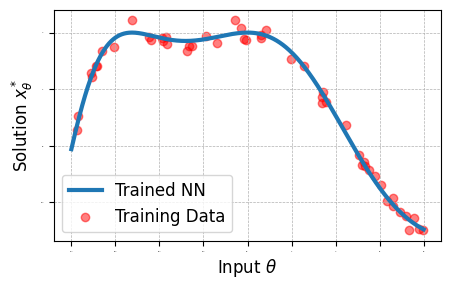

In [58]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-2, 2, 1000)
y = np.cos(-0.2*x**3+0.5*x**2+x)
x_s = np.random.uniform(-2, 2, 50)
y_s = np.cos(-0.2*x_s**3+0.5*x_s**2+x_s) + np.random.randn(50) * 0.05

plt.figure(figsize=(5, 3), alpha=0.75)
plt.plot(x, y, linewidth=3, label="Trained NN")
plt.scatter(x_s, y_s, c="red", alpha=0.5, label="Training Data")
plt.legend(loc="lower left", fontsize=12)
plt.xlabel(r"Input $\theta$", fontsize=12)
plt.ylabel(r"Solution $x_{\theta}^*$", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.xticks(fontsize=0)
plt.yticks(fontsize=0)
plt.savefig("nn_solution.png", dpi=300, bbox_inches="tight")
plt.show()


